In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"C:\Users\USER\Downloads\car_insurance.csv")
df.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [3]:
df=df.drop_duplicates()

In [4]:
df.columns

Index(['id', 'age', 'gender', 'driving_experience', 'education', 'income',
       'credit_score', 'vehicle_ownership', 'vehicle_year', 'married',
       'children', 'postal_code', 'annual_mileage', 'vehicle_type',
       'speeding_violations', 'duis', 'past_accidents', 'outcome'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  duis                 10000 non-null  

In [6]:
df.describe()

,id,age,gender,credit_score,vehicle_ownership,married,children,postal_code,annual_mileage,speeding_violations,duis,past_accidents,outcome
count,10000.000000,10000.000000,10000.000000,9018.000000,10000.000000,10000.000000,10000.000000,10000.000000,9043.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,500521.906800,1.489500,0.499000,0.515813,0.697000,0.498200,0.688800,19864.548400,11697.003207,1.482900,0.23920,1.056300,0.313300
std,290030.768758,1.025278,0.500024,0.137688,0.459578,0.500022,0.463008,18915.613855,2818.434528,2.241966,0.55499,1.652454,0.463858
min,101.000000,0.000000,0.000000,0.053358,0.000000,0.000000,0.000000,10238.000000,2000.000000,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,1.000000,0.000000,0.417191,0.000000,0.000000,0.000000,10238.000000,10000.000000,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,1.000000,0.000000,0.525033,1.000000,0.000000,1.000000,10238.000000,12000.000000,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,2.000000,1.000000,0.618312,1.000000,1.000000,1.000000,32765.000000,14000.000000,2.000000,0.00000,2.000000,1.000000
max,999976.000000,3.000000,1.000000,0.960819,1.000000,1.000000,1.000000,92101.000000,22000.000000,22.000000,6.00000,15.000000,1.000000


In [7]:
df['id'].nunique()

10000

In [8]:
#Because of unique values
del df['id']

In [9]:
df.isnull().sum()

age                      0
gender                   0
driving_experience       0
education                0
income                   0
credit_score           982
vehicle_ownership        0
vehicle_year             0
married                  0
children                 0
postal_code              0
annual_mileage         957
vehicle_type             0
speeding_violations      0
duis                     0
past_accidents           0
outcome                  0
dtype: int64

In [10]:
df['postal_code']=df['postal_code'].map({
    10238: "New York",
    32765: "Sanford",
    92101: "San Diego",
    21217: "Baltimore"
}
)
print(df['postal_code'])

0       New York
1       New York
2       New York
3        Sanford
4        Sanford
          ...   
9995    New York
9996     Sanford
9997    New York
9998    New York
9999    New York
Name: postal_code, Length: 10000, dtype: object


In [11]:
cat_cols=[c for c in df.select_dtypes(include='object').columns]
num_cols=[c for c in df.select_dtypes(exclude='object').columns]
target='outcome'

In [12]:
#Checking if target is imbalanced( it is noot :)  )
df[target].value_counts(normalize=True)

outcome
0.0    0.6867
1.0    0.3133
Name: proportion, dtype: float64

In [13]:
#We see that most of the columns have "low cardinality numeric data"
for c in df.columns:
    print(c,df[c].nunique())

age 4
gender 2
driving_experience 4
education 3
income 4
credit_score 9018
vehicle_ownership 2
vehicle_year 2
married 2
children 2
postal_code 4
annual_mileage 21
vehicle_type 2
speeding_violations 21
duis 7
past_accidents 15
outcome 2


In [14]:
df['postal_code'].value_counts()

postal_code
New York     6940
Sanford      2456
San Diego     484
Baltimore     120
Name: count, dtype: int64

In [15]:
numerics2=[c for c in num_cols if df[c].nunique()<21]

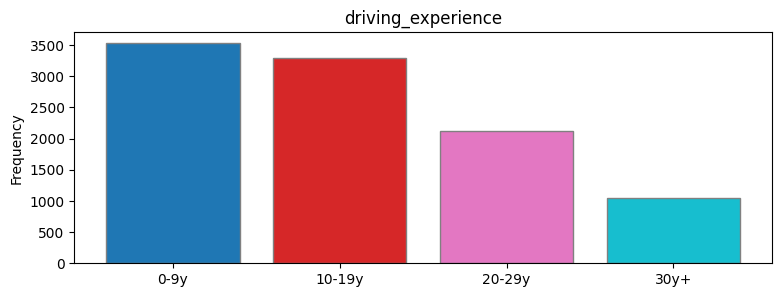

driving_experience 
 driving_experience
0-9y      3530
10-19y    3299
20-29y    2119
30y+      1052
Name: count, dtype: int64


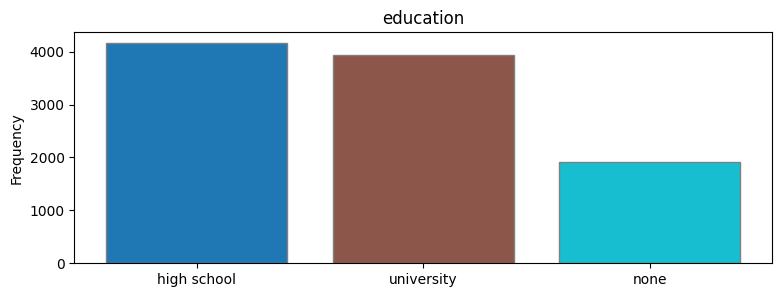

education 
 education
high school    4157
university     3928
none           1915
Name: count, dtype: int64


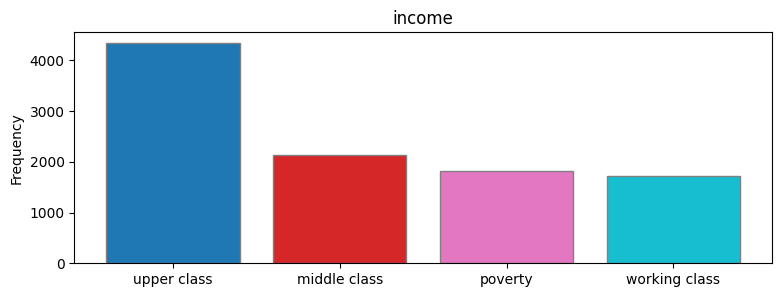

income 
 income
upper class      4336
middle class     2138
poverty          1814
working class    1712
Name: count, dtype: int64


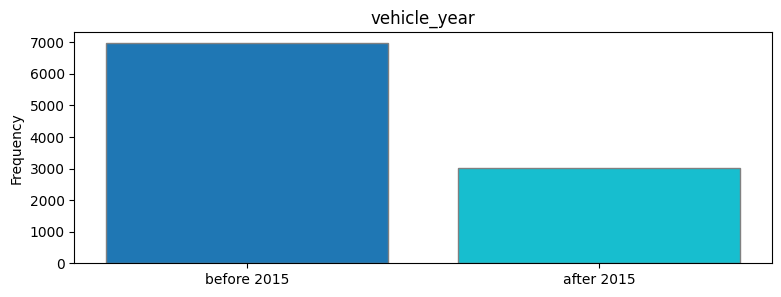

vehicle_year 
 vehicle_year
before 2015    6967
after 2015     3033
Name: count, dtype: int64


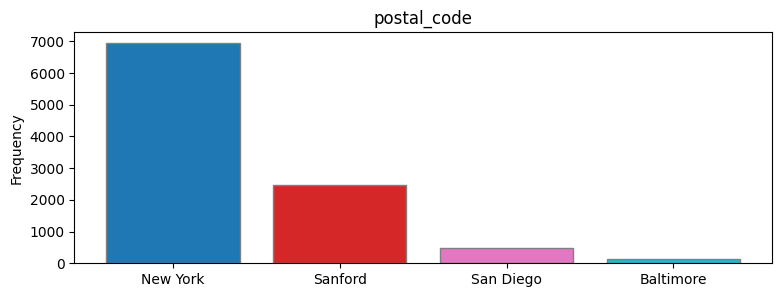

postal_code 
 postal_code
New York     6940
Sanford      2456
San Diego     484
Baltimore     120
Name: count, dtype: int64


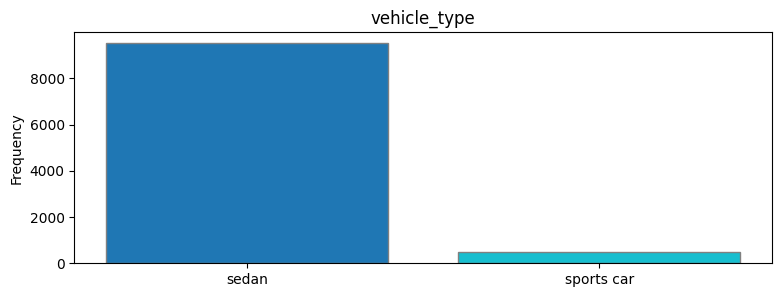

vehicle_type 
 vehicle_type
sedan         9523
sports car     477
Name: count, dtype: int64


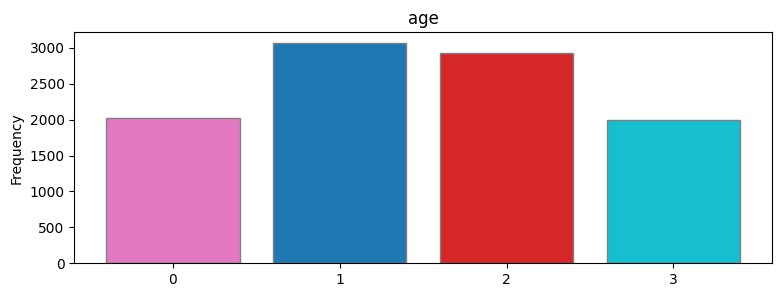

age 
 age
1    3063
2    2931
0    2016
3    1990
Name: count, dtype: int64


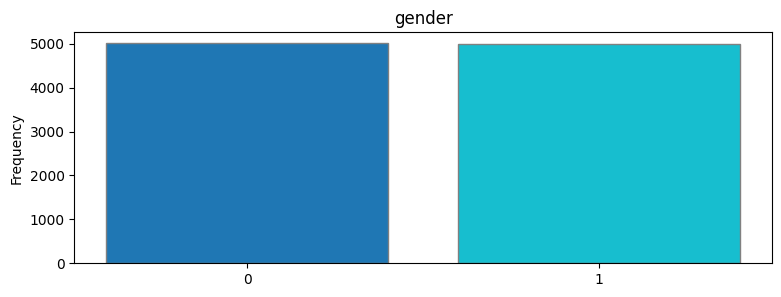

gender 
 gender
0    5010
1    4990
Name: count, dtype: int64


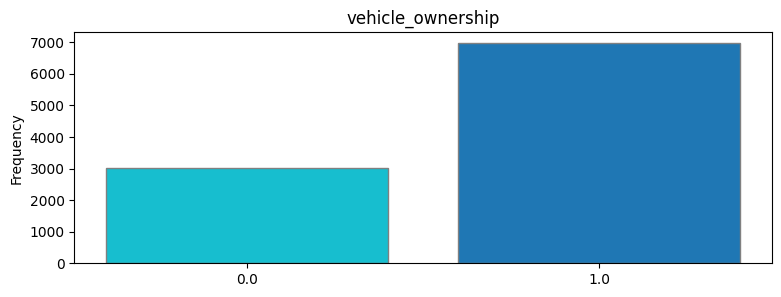

vehicle_ownership 
 vehicle_ownership
1.0    6970
0.0    3030
Name: count, dtype: int64


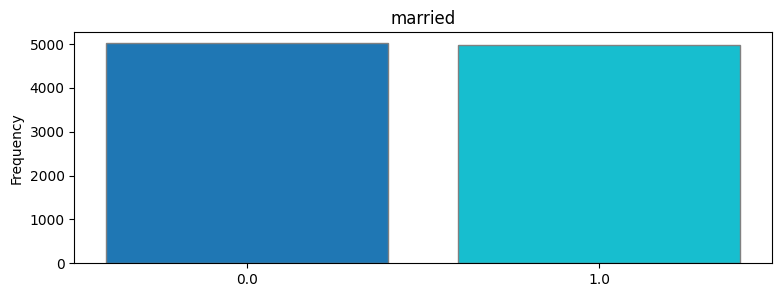

married 
 married
0.0    5018
1.0    4982
Name: count, dtype: int64


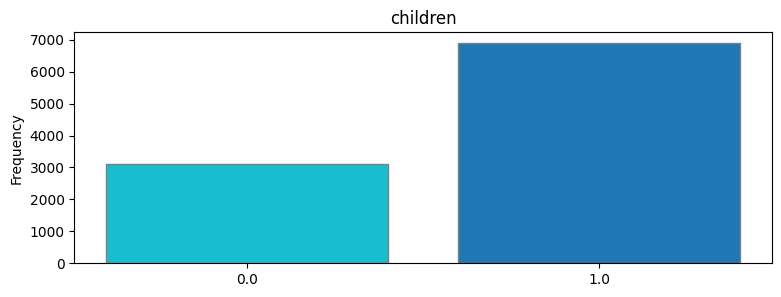

children 
 children
1.0    6888
0.0    3112
Name: count, dtype: int64


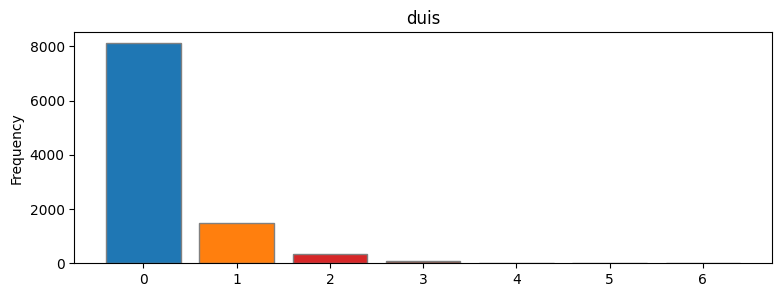

duis 
 duis
0    8118
1    1470
2     331
3      68
4      10
5       2
6       1
Name: count, dtype: int64


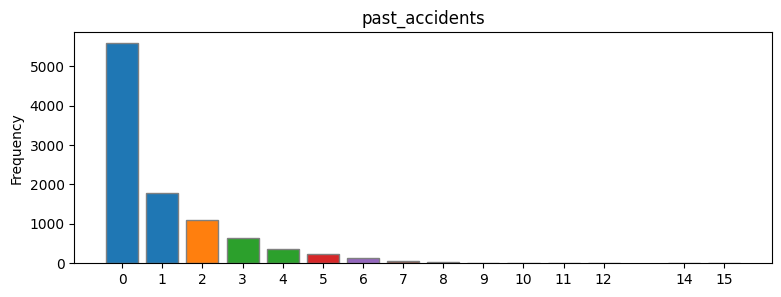

past_accidents 
 past_accidents
0     5584
1     1783
2     1104
3      646
4      366
5      232
6      144
7       61
8       41
9       19
10       9
11       7
12       2
14       1
15       1
Name: count, dtype: int64


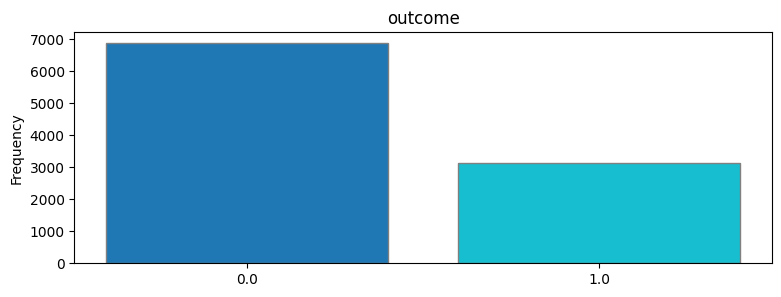

outcome 
 outcome
0.0    6867
1.0    3133
Name: count, dtype: int64


In [16]:
import matplotlib.pyplot as plt

def bar_plot(category):
    var = df[category]
    varValue = var.value_counts()
    plt.figure(figsize=(9, 3))
    colors = plt.cm.get_cmap('tab10', len(varValue))
    plt.bar(varValue.index, varValue, color=[colors(i) for i in range(len(varValue))],edgecolor='#808080')
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel('Frequency')
    plt.title(category)
    plt.show()
    print(f'{category} \n {varValue}')

cat_col = [col for col in df.columns if df[col].dtype == 'object']

num_low_card = [col for col in df.select_dtypes(include=['number']).columns if df[col].nunique() < 21]

all_cols_to_plot = cat_col + num_low_card

for c in all_cols_to_plot:
    bar_plot(c)


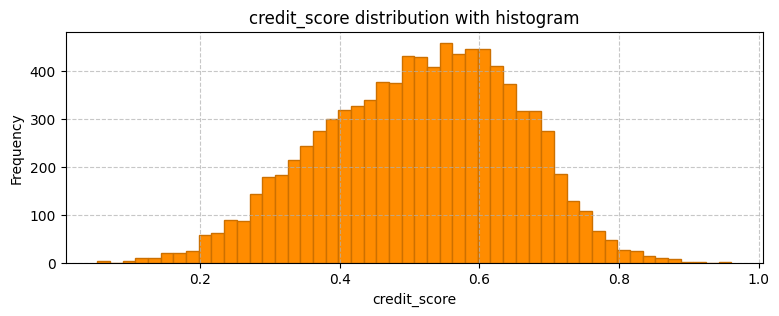

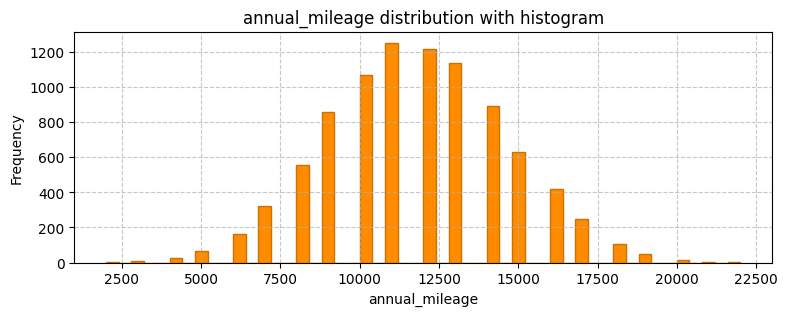

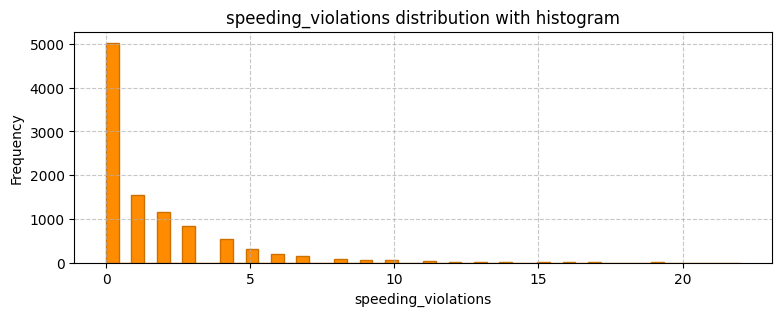

In [17]:

def plot_hist(category):
    plt.figure(figsize=(9, 3))
    plt.hist(df[category], bins=50, color='#FF8C00', edgecolor='#CC7000')  
    plt.xlabel(category)
    plt.ylabel('Frequency')
    plt.title(f'{category} distribution with histogram')
    
    
    plt.grid(True, linestyle='--', alpha=0.7)  
    
    plt.show()



for c in df.columns:
  if c not in all_cols_to_plot:
    plot_hist(c)

In [18]:
df.isnull().sum()

age                      0
gender                   0
driving_experience       0
education                0
income                   0
credit_score           982
vehicle_ownership        0
vehicle_year             0
married                  0
children                 0
postal_code              0
annual_mileage         957
vehicle_type             0
speeding_violations      0
duis                     0
past_accidents           0
outcome                  0
dtype: int64

In [19]:
 #* When we pay attention to the graphics, we can see that:
# Most of the drivers:

# Have few to moderate experience
# When we pay attention to the graphics, we can see that:
# Are mostly educated
# Have upper-class income
# Drive old cars
# Are from New York
# Drive sedan cars
# Are middle-aged (26-64)   0,1,2,3   16-26  26-40  40-64 65+
# Own their vehicles
# Have children
# Are good drivers (since DUIs,past accidents and speeding violations are 0 for most)
# Mainly do not file claims(we can know easily that good drivers cant demand)

# The number of female and male drivers, as well as married and unmarried individuals, is roughly the same.

In [20]:
#For Seeing which features affect to claim most:
for c in cat_cols:
    if c!='outcome':
        print(df[[c, target]].groupby([c], as_index = False).mean().sort_values(
        by = target,
        ascending = False
    ))
        print()
        

  driving_experience   outcome
0               0-9y  0.628045
1             10-19y  0.238557
2             20-29y  0.051439
3               30y+  0.019011

     education  outcome
1         none  0.47154
0  high school  0.32331
2   university  0.22556

          income   outcome
1        poverty  0.653804
3  working class  0.453271
0   middle class  0.276894
2    upper class  0.133533

  vehicle_year   outcome
1  before 2015  0.403330
0   after 2015  0.106495

  postal_code   outcome
0   Baltimore  1.000000
2   San Diego  0.413223
3     Sanford  0.377443
1    New York  0.271758

  vehicle_type   outcome
1   sports car  0.324948
0        sedan  0.312717



In [21]:
# New York City  Baltimore
# San Diego, CA: San Diego
# Baltimore, MD: Sanford
# Sanford, FL:   New York

In [22]:
 #!The most suprising facts:
 #! why duis and past_accidents have negative correlations with demands?

In [23]:
#!neye gore dah az ehalisi olanlar daha risklidir?

In [24]:
pd.pivot_table(df, index = target, values = [c for c in num_cols if c not in all_cols_to_plot])

,annual_mileage,credit_score,speeding_violations
outcome,,,
0.0,11342.852559,0.546092,1.924858
1.0,12482.562278,0.449571,0.514204


In [25]:
for c in num_cols:
    print(c,df[c].corr(df[target]))

age -0.44846287421928627
gender 0.10720768380886138
credit_score -0.3252858479628991
vehicle_ownership -0.37892145489132867
married -0.26210365863509466
children -0.23283536915446107
annual_mileage 0.18715416976628735
speeding_violations -0.29186168982025995
duis -0.18935217385090275
past_accidents -0.3114954247419295
outcome 1.0


In [26]:
 #!The most suprising insights:
 #! why speeding_violations  have negative correlations with demands?

In [27]:
df.dtypes

age                      int64
gender                   int64
driving_experience      object
education               object
income                  object
credit_score           float64
vehicle_ownership      float64
vehicle_year            object
married                float64
children               float64
postal_code             object
annual_mileage         float64
vehicle_type            object
speeding_violations      int64
duis                     int64
past_accidents           int64
outcome                float64
dtype: object

In [28]:
for c in all_cols_to_plot:
    print(df[c].value_counts())

driving_experience
0-9y      3530
10-19y    3299
20-29y    2119
30y+      1052
Name: count, dtype: int64
education
high school    4157
university     3928
none           1915
Name: count, dtype: int64
income
upper class      4336
middle class     2138
poverty          1814
working class    1712
Name: count, dtype: int64
vehicle_year
before 2015    6967
after 2015     3033
Name: count, dtype: int64
postal_code
New York     6940
Sanford      2456
San Diego     484
Baltimore     120
Name: count, dtype: int64
vehicle_type
sedan         9523
sports car     477
Name: count, dtype: int64
age
1    3063
2    2931
0    2016
3    1990
Name: count, dtype: int64
gender
0    5010
1    4990
Name: count, dtype: int64
vehicle_ownership
1.0    6970
0.0    3030
Name: count, dtype: int64
married
0.0    5018
1.0    4982
Name: count, dtype: int64
children
1.0    6888
0.0    3112
Name: count, dtype: int64
duis
0    8118
1    1470
2     331
3      68
4      10
5       2
6       1
Name: count, dtype: int64
pas

In [29]:
df['vehicle_year']=(df['vehicle_year']=='before 2015').astype(int)

In [30]:
df['vehicle_type']=(df['vehicle_type']=='sedan').astype(int)

In [31]:
df = pd.get_dummies(df, columns=['postal_code'])

In [32]:
df

,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome,postal_code_Baltimore,postal_code_New York,postal_code_San Diego,postal_code_Sanford
0,3,0,0-9y,high school,upper class,0.629027,1.0,0,0.0,1.0,12000.0,1,0,0,0,0.0,False,True,False,False
1,0,1,0-9y,none,poverty,0.357757,0.0,1,0.0,0.0,16000.0,1,0,0,0,1.0,False,True,False,False
2,0,0,0-9y,high school,working class,0.493146,1.0,1,0.0,0.0,11000.0,1,0,0,0,0.0,False,True,False,False
3,0,1,0-9y,university,working class,0.206013,1.0,1,0.0,1.0,11000.0,1,0,0,0,0.0,False,False,False,True
4,1,1,10-19y,none,working class,0.388366,1.0,1,0.0,0.0,12000.0,1,2,0,1,1.0,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,0,10-19y,university,upper class,0.582787,1.0,1,0.0,0.0,16000.0,1,0,0,1,0.0,False,True,False,False
9996,1,0,10-19y,none,middle class,0.522231,1.0,0,0.0,1.0,NaN,1,1,0,0,0.0,False,False,False,True
9997,1,1,0-9y,high school,middle class,0.470940,1.0,1,0.0,1.0,14000.0,1,0,0,0,0.0,False,True,False,False
9998,1,0,10-19y,high school,poverty,0.364185,0.0,1,0.0,1.0,13000.0,1,2,0,1,1.0,False,True,False,False


In [33]:
df['driving_experience']=df['driving_experience'].map({'0-9y':0,'10-19y':1,'20-29y':2,'30y+':3})

In [34]:
df['education']=df['education'].map({'high school':1,'university':2,'none':0 })

In [35]:
df['income'] = df['income'].map({'upper class': 0, 'middle class': 1, 'poverty': 3, 'working class': 2})

In [36]:
df.dtypes

age                        int64
gender                     int64
driving_experience         int64
education                  int64
income                     int64
credit_score             float64
vehicle_ownership        float64
vehicle_year               int32
married                  float64
children                 float64
annual_mileage           float64
vehicle_type               int32
speeding_violations        int64
duis                       int64
past_accidents             int64
outcome                  float64
postal_code_Baltimore       bool
postal_code_New York        bool
postal_code_San Diego       bool
postal_code_Sanford         bool
dtype: object

In [37]:
for c in df.columns:
    if df[c].nunique()==2:
        df[c]=df[c].astype(int)

In [38]:
df.dtypes

age                        int64
gender                     int32
driving_experience         int64
education                  int64
income                     int64
credit_score             float64
vehicle_ownership          int32
vehicle_year               int32
married                    int32
children                   int32
annual_mileage           float64
vehicle_type               int32
speeding_violations        int64
duis                       int64
past_accidents             int64
outcome                    int32
postal_code_Baltimore      int32
postal_code_New York       int32
postal_code_San Diego      int32
postal_code_Sanford        int32
dtype: object

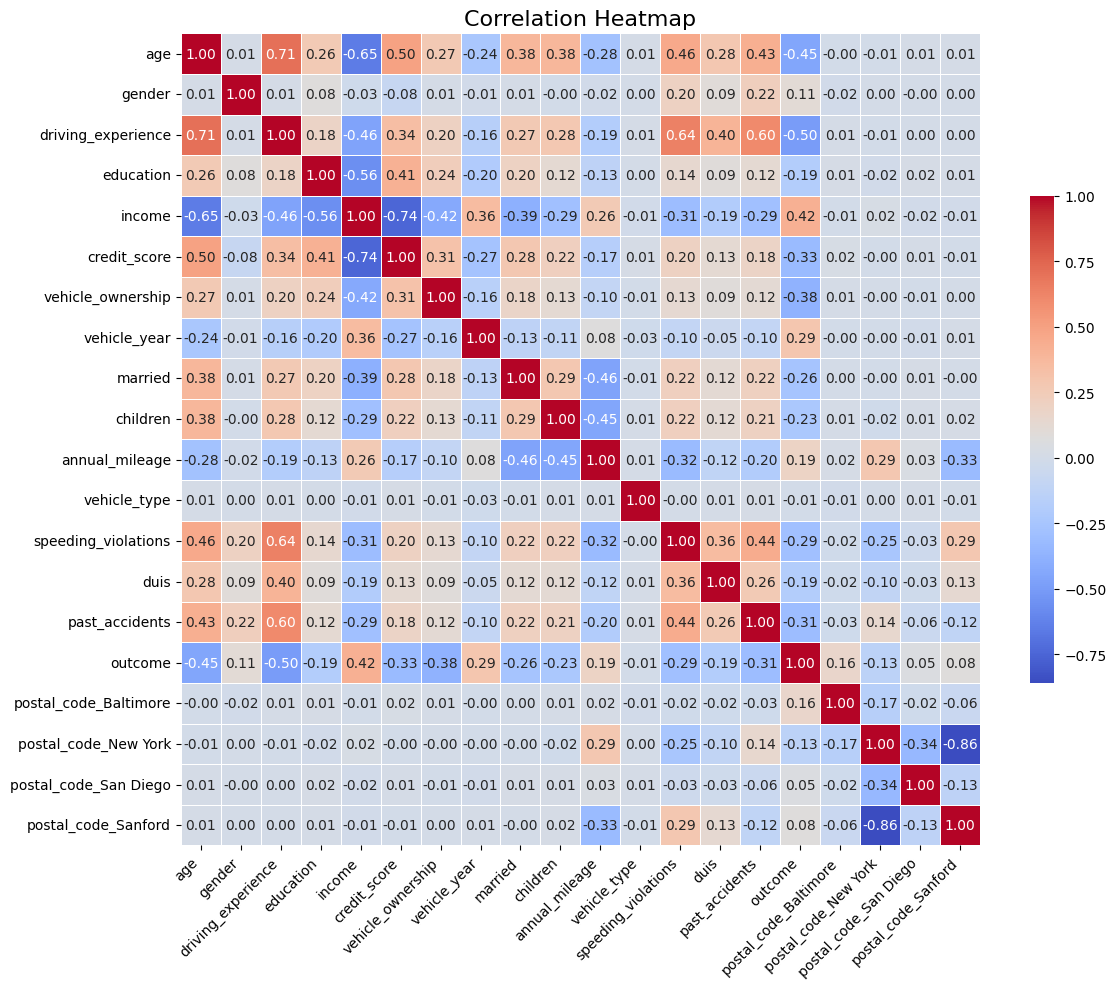

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'data' is your DataFrame
data = df

# Compute the correlation matrix
corr = data.corr()

# Choose a different colormap, e.g., 'coolwarm'
cmap = sns.color_palette("coolwarm", as_cmap=True)

# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(12, 10))

# Draw the heatmap without the mask
sns.heatmap(corr, cmap=cmap, vmax=1, annot=True,
            fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.6})

# Set title and adjust layout
ax.set_title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [40]:
del df['postal_code_San Diego']
del df['postal_code_Sanford']
del df['vehicle_type']

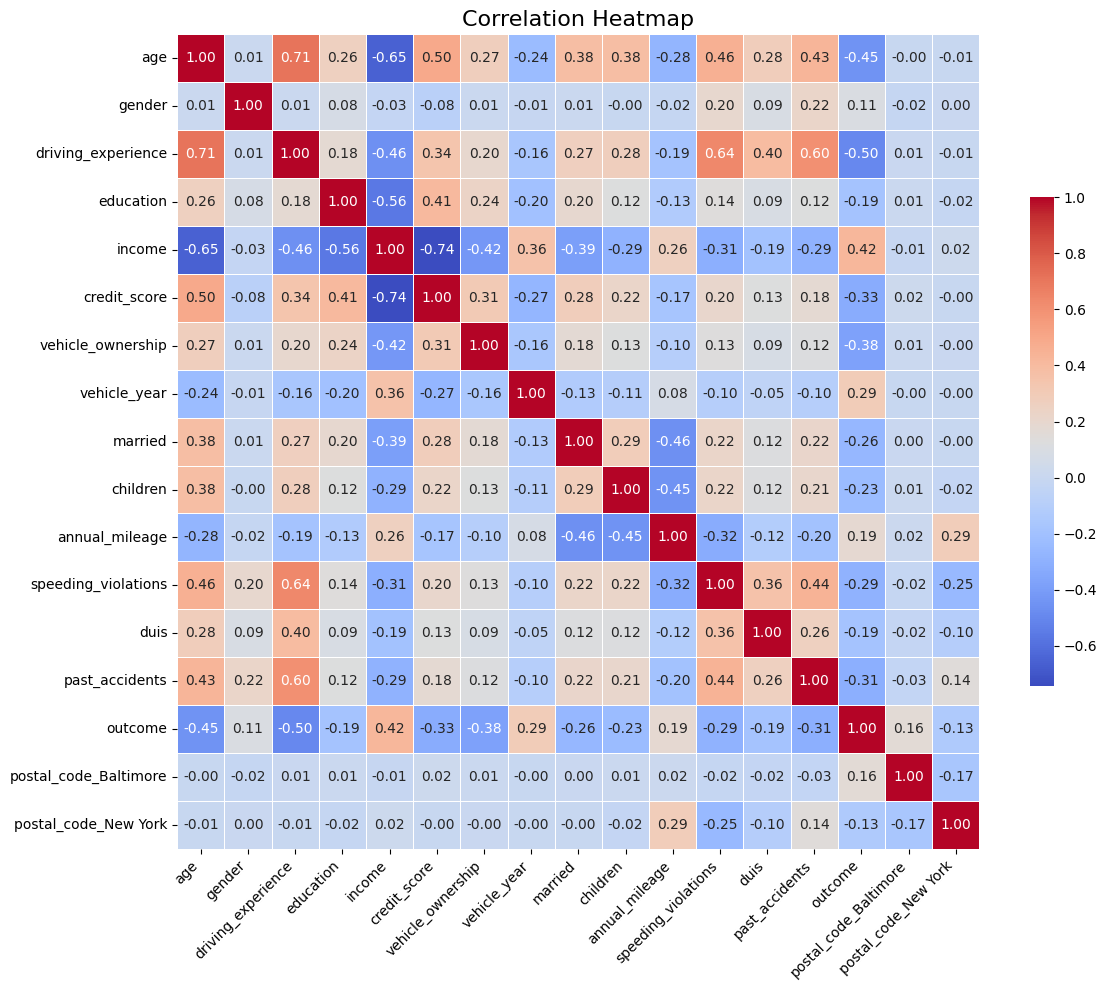

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'data' is your DataFrame
data = df

# Compute the correlation matrix
corr = data.corr()

# Choose a different colormap, e.g., 'coolwarm'
cmap = sns.color_palette("coolwarm", as_cmap=True)

# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(12, 10))

# Draw the heatmap without the mask
sns.heatmap(corr, cmap=cmap, vmax=1, annot=True,
            fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.6})

# Set title and adjust layout
ax.set_title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



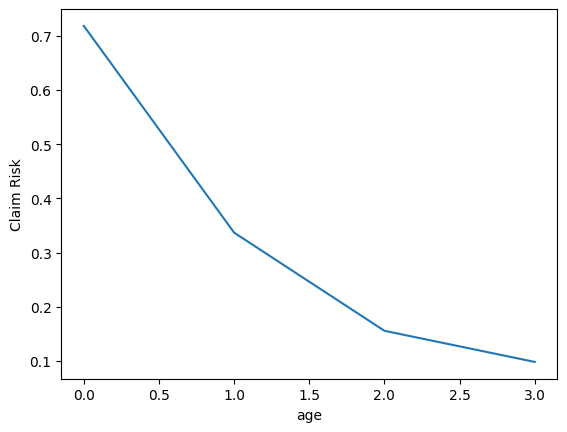

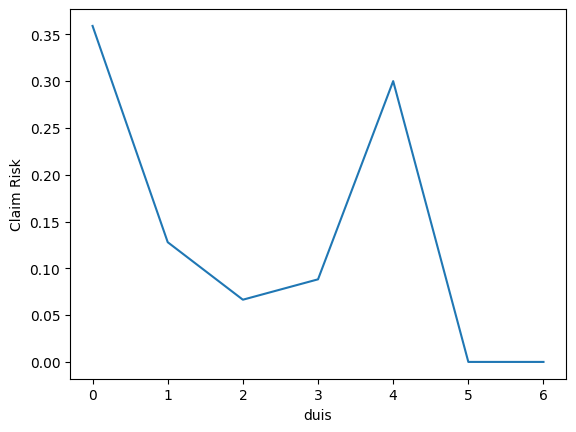

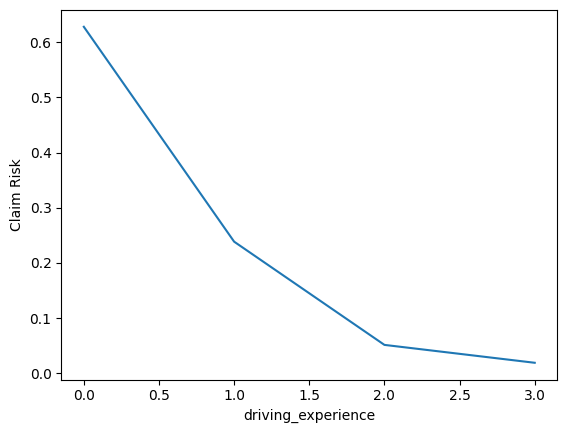

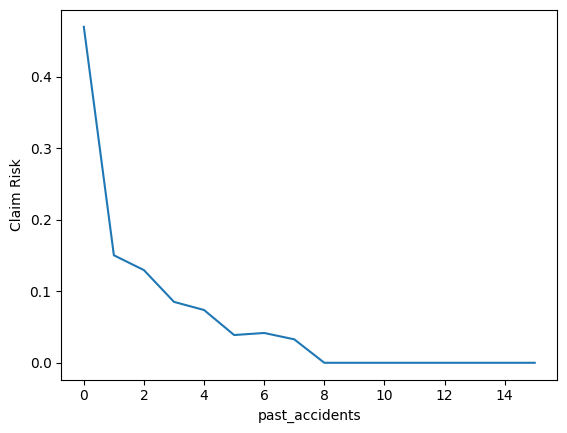

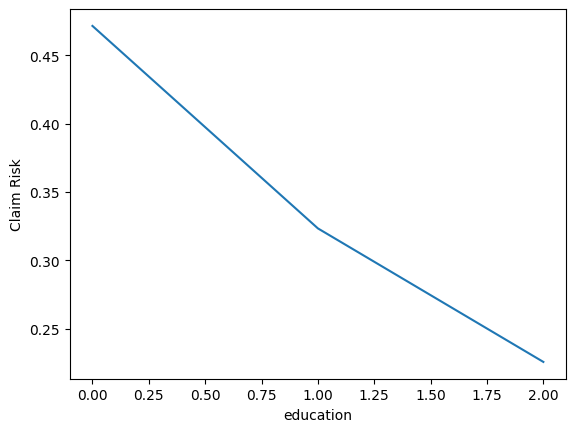

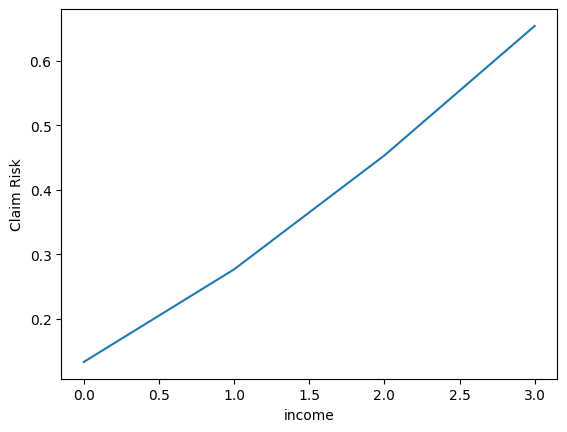

In [42]:
for c in ['age','duis','driving_experience','past_accidents','education','income']:
    plt.plot(df.groupby(by = [c]).aggregate({'outcome':'mean'}))
    plt.xlabel(c)
    plt.ylabel('Claim Risk')
    plt.show()

In [43]:
def Feature_Function(df: pd.DataFrame, target: str):
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found in the dataframe")
    
    numerical_c = [c for c in df.select_dtypes(include=['int64', 'float64']) if df[c].nunique() != 2]
    
    new_dict = {}
    for c in numerical_c:
        feature_dict = {
            f'{c}>mean+std': df[c] > (df[c].mean() + df[c].std()),
            f'{c}<mean+std': df[c] < (df[c].mean() + df[c].std()),
            f'{c}_>mean': df[c] > df[c].mean(),
            f'{c}_<mean': df[c] < df[c].mean(),
            f'{c}_>q3': df[c] > df[c].quantile(0.75),
            f'{c}_<0.9': df[c] < df[c].quantile(0.9),
            f'{c}_log': np.log1p(df[c]),  
            f'{c}_sqrt': np.sqrt(df[c]),
        }
        for p in range(4, 10):
            feature_dict[f'{c}_power_{p}'] = np.power(df[c], p)
        
        for i in np.arange(0.1, 1.1, 0.1):
            feature_dict[f'{c}_power_{i}'] = np.power(df[c], i)

        real_corr = abs(df[c].corr(df[target]))
        best_corr = real_corr
        best_feature = None

        for feature_name, feature_values in feature_dict.items():
            new_corr = abs(feature_values.corr(df[target]))
            if new_corr > best_corr:
                print(f'New feature: {feature_name} | Original corr: {real_corr}, New corr: {new_corr}')
                best_corr = new_corr
                best_feature = feature_name

        if best_feature:
            new_dict[best_feature] = best_corr

    print('Best results:')
    return new_dict

# Assuming 't' is your target column name and 'df' is your DataFrame
t = 'outcome'  # Replace with your actual target column name
new_features_dict = Feature_Function(df, t)
print(new_features_dict)


New feature: age_log | Original corr: 0.44846287421928627, New corr: 0.47481633211977237
New feature: age_sqrt | Original corr: 0.44846287421928627, New corr: 0.4782836794241044
New feature: age_power_0.4 | Original corr: 0.44846287421928627, New corr: 0.4785377169401566
New feature: driving_experience_log | Original corr: 0.49743104347069905, New corr: 0.5241176992899829
New feature: driving_experience_sqrt | Original corr: 0.49743104347069905, New corr: 0.5275903456337325
New feature: driving_experience_power_0.4 | Original corr: 0.49743104347069905, New corr: 0.5279768273370271
New feature: education_log | Original corr: 0.18935686909626842, New corr: 0.1910039921258852
New feature: education_power_0.7000000000000001 | Original corr: 0.18935686909626842, New corr: 0.1911170459938091
New feature: credit_score_log | Original corr: 0.3252858479628991, New corr: 0.3262282497624051
New feature: annual_mileage_power_4 | Original corr: 0.18715416976628735, New corr: 0.19482576905585164
New

In [44]:
df['past_accidents']=np.sqrt(df['past_accidents'])
df['age']=np.sqrt(df['age'])
df['income']=df['income']>df['income'].mean()
df['speeding_violations']=np.power(df['speeding_violations'],0.1)

In [45]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from collections import Counter

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-whitegrid")

from sklearn.impute import KNNImputer

from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix

from sklearn.tree import DecisionTreeClassifier as dtc, plot_tree, export_graphviz
import pydotplus
from IPython.display import Image

In [46]:
# from sklearn.ensemble import RandomForestRegressor
# def fill_missing_values_with_ml(df, target_column, features, model=None):
#     train_data = df[df[target_column].notna()]
#     test_data = df[df[target_column].isna()]
#     X_train = train_data[features]
#     y_train = train_data[target_column]
#     X_test = test_data[features]
#     if model is None:
#         model = RandomForestRegressor(random_state=42)
    
#     model.fit(X_train, y_train)
#     predictions = model.predict(X_test)
#     df.loc[df[target_column].isna(), target_column] = predictions

#     return df
# features =  df.drop(columns = ['credit_score','annual_mileage']).columns
# for i in ['credit_score','annual_mileage']:
#     fill_missing_values_with_ml(df,i,features)

In [47]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler'ı oluştur
scaler = MinMaxScaler()

# Sütunu normalize et ve DataFrame'e geri ekle
df['annual_mileage'] = scaler.fit_transform(df[['annual_mileage']])


In [48]:
import pandas as pd
from sklearn.impute import KNNImputer


# Rəqəmsal sütunları seçin
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# KNN imputer qurun (k = 5, yəni ən yaxın 5 qonşunu istifadə edəcəyik)
imputer = KNNImputer(n_neighbors=5)

# Rəqəmsal sütunları impute edin
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Nəticələri çap edin
print(df.isnull().sum())  # Boş dəyərlərin qalıb-qalmadığını yoxlayın


age                      0
gender                   0
driving_experience       0
education                0
income                   0
credit_score             0
vehicle_ownership        0
vehicle_year             0
married                  0
children                 0
annual_mileage           0
speeding_violations      0
duis                     0
past_accidents           0
outcome                  0
postal_code_Baltimore    0
postal_code_New York     0
dtype: int64


In [49]:
target

'outcome'

In [50]:
y = df[target]
X = df.drop(target, axis=1)
df=df.sample(frac=1)
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.35)

In [51]:
xgb_model = xgb.XGBClassifier(n_estimetors = 5, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_f1_score = f1_score(y_test, xgb_predictions)
print(f"XGBoost Accuracy: {xgb_accuracy}")
print(f"XGBoost F1 score: {xgb_f1_score}")

XGBoost Accuracy: 0.8348571428571429
XGBoost F1 score: 0.7382246376811594


In [52]:

# import xgboost as xgb
# from sklearn.metrics import accuracy_score, f1_score
# from sklearn.model_selection import train_test_split

# # Parametre aralıklarını belirliyoruz
# n_estimators_range = range(1, 11)
# max_depth_range = range(1, 11)

# # Sonuçları saklamak için bir liste oluşturuyoruz
# results = []

# # Döngü içinde parametre kombinasyonlarını deniyoruz
# for n_estimators in n_estimators_range:
#     for max_depth in max_depth_range:
#         # Modeli oluştur ve eğit
#         xgb_model = xgb.XGBClassifier(n_estimators=n_estimators, 
#                                       max_depth=max_depth, 
#                                       random_state=42,average='weighted')
#         xgb_model.fit(X_train, y_train)
        
#         # Test seti üzerinde tahmin yap
#         xgb_predictions = xgb_model.predict(X_test)
        
#         # Doğruluk ve F1 skorlarını hesapla
#         xgb_accuracy = accuracy_score(y_test, xgb_predictions)
#         xgb_f1_score = f1_score(y_test, xgb_predictions)
        
#         # Sonuçları listeye ekle
#         results.append((n_estimators, max_depth, xgb_accuracy, xgb_f1_score))

#         # Sonuçları yazdır
#         print(f"n_estimators: {n_estimators}, max_depth: {max_depth}")
#         print(f"XGBoost Accuracy: {xgb_accuracy}")
#         print(f"XGBoost F1 score: {xgb_f1_score}")
#         print('----------------------------')

# # En iyi sonuçları bulmak için sonuçları F1 skoruna göre sıralayabilirsin
# best_result = max(results, key=lambda x: x[3])  # F1 skoru en yüksek olanı buluyoruz
# print(f"En iyi F1 skoru: {best_result[3]} - n_estimators: {best_result[0]}, max_depth: {best_result[1]}")
# print(f"Bu kombinasyona karşılık gelen Accuracy: {best_result[2]}")


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# Parametre aralıklarını belirliyoruz
n_estimators_range = range(1, 11)
min_samples_leaf_range = range(1, 11)

# Sonuçları saklamak için bir liste oluşturuyoruz
results = []

# Döngü içinde parametre kombinasyonlarını deniyoruz
for n_estimators in n_estimators_range:
    for min_samples_leaf in min_samples_leaf_range:
        # Modeli oluştur ve eğit
        rf_model = RandomForestClassifier(n_estimators=n_estimators, 
                                          min_samples_leaf=min_samples_leaf, 
                                          class_weight='balanced', 
                                          random_state=42)
        rf_model.fit(X_train, y_train)
        
        # Test seti üzerinde tahmin yap
        rf_predictions = rf_model.predict(X_test)
        
        # Doğruluk ve F1 skorlarını hesapla
        rf_accuracy = accuracy_score(y_test, rf_predictions)
        rf_f1_score = f1_score(y_test, rf_predictions)
        
        # Sonuçları listeye ekle
        results.append((n_estimators, min_samples_leaf, rf_accuracy, rf_f1_score))

        # Sonuçları yazdır
        print(f"n_estimators: {n_estimators}, min_samples_leaf: {min_samples_leaf}")
        print(f"Random Forest Accuracy: {rf_accuracy}")
        print(f"Random Forest F1 score: {rf_f1_score}")
        print('----------------------------')

# En iyi sonuçları bulmak için sonuçları F1 skoruna göre sıralayabilirsin
best_result = max(results, key=lambda x: x[3])  # F1 skoru en yüksek olanı buluyoruz
print(f"En iyi F1 skoru: {best_result[3]},Accuracy: {best_result[2]} - n_estimators: {best_result[0]}, min_samples_leaf: {best_result[1]}")


n_estimators: 1, min_samples_leaf: 1
Random Forest Accuracy: 0.7717142857142857
Random Forest F1 score: 0.637312755333636
----------------------------
n_estimators: 1, min_samples_leaf: 2
Random Forest Accuracy: 0.7771428571428571
Random Forest F1 score: 0.685230024213075
----------------------------
n_estimators: 1, min_samples_leaf: 3
Random Forest Accuracy: 0.7782857142857142
Random Forest F1 score: 0.690343176376696
----------------------------
n_estimators: 1, min_samples_leaf: 4
Random Forest Accuracy: 0.7877142857142857
Random Forest F1 score: 0.7050416832076221
----------------------------
n_estimators: 1, min_samples_leaf: 5
Random Forest Accuracy: 0.7851428571428571
Random Forest F1 score: 0.6975060337892196
----------------------------
n_estimators: 1, min_samples_leaf: 6
Random Forest Accuracy: 0.7991428571428572
Random Forest F1 score: 0.709863805200165
----------------------------
n_estimators: 1, min_samples_leaf: 7
Random Forest Accuracy: 0.7968571428571428
Random Fores

In [54]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

# Proqnozlaşdırma
lr_predictions = lr_model.predict(X_test)

# Dəqiqlik və F1 skorunun hesablanması
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_f1_score = f1_score(y_test, lr_predictions)

print(f"Logistic Regression Accuracy: {lr_accuracy}")
print(f"Logistic Regression F1 score: {lr_f1_score}")

Logistic Regression Accuracy: 0.8457142857142858
Logistic Regression F1 score: 0.7504621072088725


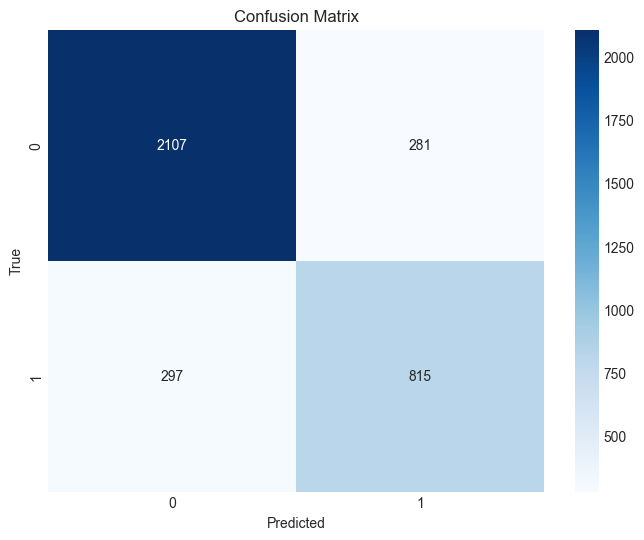

In [55]:
# Create confusion matrix
conf_matrix = confusion_matrix(y_test, xgb_predictions)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=xgb_model.classes_, yticklabels=xgb_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

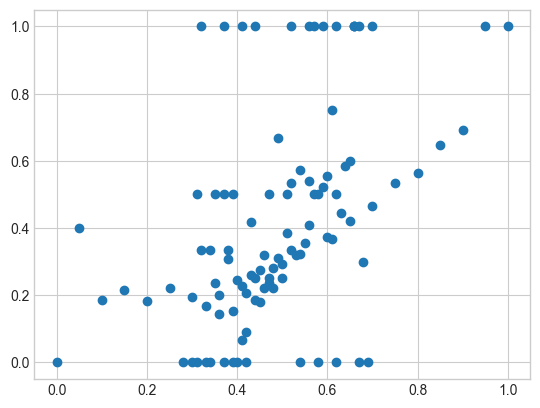

In [56]:
xs = []
ys = []

map = {}
for i in df['annual_mileage'].unique():
    xs.append(i)
    value = df[ df['annual_mileage'] == i ]['outcome'].mean()
    ys.append( value )

    map[ i ] = value

plt.scatter(xs,ys)
plt.show()

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

model = DecisionTreeClassifier(random_state=42)

# Modeli təlim edin
model.fit(X_train, y_train)

# Test dəsti ilə proqnozlar edin
y_pred = model.predict(X_test)

# Accuracy və F1-Score-u hesablayın
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')  # Weighted average for imbalanced classes

# Nəticələri çap edin
print(f"Modelin doğruluğu (Accuracy): {accuracy:.2f}")
print(f"Modelin F1-Score göstəricisi: {f1:.2f}")


Modelin doğruluğu (Accuracy): 0.78
Modelin F1-Score göstəricisi: 0.78


In [58]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
clf = LinearDiscriminantAnalysis()
clf.fit(df.drop(columns = ['outcome']), df['outcome'])
r = clf.predict( df.drop(columns = ['outcome']) )

df['LDA_result'] = r
print(df['LDA_result'].corr(df['outcome'])) 

0.6369196970697751


In [59]:
df

,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,annual_mileage,speeding_violations,duis,past_accidents,outcome,postal_code_Baltimore,postal_code_New York,LDA_result
1787,1.000000,1,0.0,1.0,False,0.497445,1,1,0,0,0.65,0.000000,0.0,0.000000,0,0,1,1
1174,0.000000,0,0.0,0.0,True,0.286204,0,1,0,0,0.70,0.000000,0.0,0.000000,1,0,1,1
7676,1.414214,0,1.0,1.0,True,0.423926,0,1,1,1,0.45,1.071773,0.0,1.000000,0,0,1,0
5706,1.414214,0,2.0,1.0,False,0.626082,0,0,1,1,0.10,1.116123,0.0,1.000000,0,0,0,0
5219,0.000000,1,0.0,0.0,True,0.273986,0,1,0,0,0.45,0.000000,0.0,0.000000,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8781,1.000000,0,1.0,1.0,True,0.343630,1,0,0,1,0.55,0.000000,0.0,0.000000,0,0,1,0
6992,1.414214,0,2.0,1.0,True,0.410918,1,1,1,1,0.40,0.000000,0.0,0.000000,0,0,1,0
9548,1.732051,0,3.0,2.0,False,0.613290,1,1,0,1,0.65,1.000000,2.0,0.000000,0,0,0,0
7961,0.000000,0,0.0,1.0,True,0.237014,0,1,0,1,0.50,0.000000,0.0,0.000000,0,0,1,1


In [60]:
df.corr()[target]

age                     -0.478284
gender                   0.107208
driving_experience      -0.497431
education               -0.189357
income                   0.386851
credit_score            -0.325698
vehicle_ownership       -0.378921
vehicle_year             0.294178
married                 -0.262104
children                -0.232835
annual_mileage           0.189107
speeding_violations     -0.389417
duis                    -0.189352
past_accidents          -0.382586
outcome                  1.000000
postal_code_Baltimore    0.163161
postal_code_New York    -0.134879
LDA_result               0.636920
Name: outcome, dtype: float64

In [61]:
df['sp/vio==0']=(df['speeding_violations']>0).astype(int)

In [62]:
df['duis'].value_counts()

duis
0.0    8118
1.0    1470
2.0     331
3.0      68
4.0      10
5.0       2
6.0       1
Name: count, dtype: int64

In [63]:
df['duis(0 or not)']=(df['duis']==0).astype(int)